In [1]:
!pip install econml

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

# =====================================================
# Load Dataset
# =====================================================

df = pd.read_csv("/Users/ameypatil/Desktop/Tata Power/data/2024 data/with socio/summer_2024.csv")

df = df.dropna().reset_index(drop=True)

# =====================================================
# Outcome
# =====================================================

Y = df["wdLoad"].values

# =====================================================
# Treatments
# Temperature and Relative Humidity
# =====================================================

T = df[
    [
        "temp",
        "rh"
    ]
].values

# =====================================================
# Confounders / Adjustment Variables
# =====================================================

X = df[
    [
        "hour",
        "weekend",
        "holiday",
        "festival",
        "office_hours"
    ]
].values

# =====================================================
# Causal Forest
# =====================================================

model = CausalForestDML(

    model_y=RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),

    model_t=MultiOutputRegressor(
        RandomForestRegressor(
            n_estimators=300,
            random_state=42
        )
    ),

    n_estimators=500,

    min_samples_leaf=10,

    random_state=42
)

# =====================================================
# Train Model
# =====================================================

model.fit(
    Y,
    T,
    X=X
)

# =====================================================
# Conditional Marginal Effects
# =====================================================

effects = model.const_marginal_effect(X)

temp_effect = effects[:, 0]
rh_effect = effects[:, 1]

# =====================================================
# Average Marginal Effect
# =====================================================

ate_temp = np.mean(temp_effect)
ate_rh = np.mean(rh_effect)

print("\n========== SUMMER WEATHER EFFECTS ==========")

print("Average Marginal Effect (Temperature → Load):",
      ate_temp)

print("Average Marginal Effect (Humidity → Load):",
      ate_rh)

# =====================================================
# Treatment Statistics
# =====================================================

print("\n========== TREATMENT STATISTICS ==========")

print("Temperature range:",
      df["temp"].min(),
      "to",
      df["temp"].max())

print("Humidity range:",
      df["rh"].min(),
      "to",
      df["rh"].max())

print("\nOffice Hours distribution:")
print(df["office_hours"].value_counts())


========== SUMMER WEATHER EFFECTS ==========
Average Marginal Effect (Temperature → Load): 12.420236154806647
Average Marginal Effect (Humidity → Load): 1.376762599986432

========== TREATMENT STATISTICS ==========
Temperature range: 19.0 to 40.0
Humidity range: 18.2 to 92.0

Office Hours distribution:
office_hours
0    5520
1    3312
Name: count, dtype: int64


In [3]:
# ============================================================
# WEATHER CAUSAL EFFECT + CONFIDENCE INTERVAL
# ============================================================

# Individual conditional marginal effects
effects = model.const_marginal_effect(X)

temp_effect = effects[:, 0]
rh_effect = effects[:, 1]

# Average marginal effects
ate_temp = np.mean(temp_effect)
ate_rh = np.mean(rh_effect)

print("Temperature Average Marginal Effect:", ate_temp)
print("Humidity Average Marginal Effect:", ate_rh)

# ============================================================
# CONFIDENCE INTERVALS FOR WEATHER EFFECTS
# ============================================================

# Get inference results object
inference_results = model.const_marginal_effect_inference(X)

# Use .conf_int() to get the confidence intervals.
# It returns a tuple of two arrays: (lower_bounds_per_sample, upper_bounds_per_sample)
# Each array has shape (n_samples, n_treatments).
lower_bounds_per_sample, upper_bounds_per_sample = inference_results.conf_int(alpha=0.05) # 95% CI

print("\nShape of lower_bounds_per_sample:", np.shape(lower_bounds_per_sample))
print("Shape of upper_bounds_per_sample:", np.shape(upper_bounds_per_sample))
print("Lower bounds (first 5 samples):\n", lower_bounds_per_sample[:5])
print("Upper bounds (first 5 samples):\n", upper_bounds_per_sample[:5])

# Calculate the average of the lower and upper bounds for each treatment across all samples
temp_ci_lower = np.mean(lower_bounds_per_sample[:, 0])
temp_ci_upper = np.mean(upper_bounds_per_sample[:, 0])
temp_ci_final = np.array([temp_ci_lower, temp_ci_upper])

rh_ci_lower = np.mean(lower_bounds_per_sample[:, 1])
rh_ci_upper = np.mean(upper_bounds_per_sample[:, 1])
rh_ci_final = np.array([rh_ci_lower, rh_ci_upper])

print("\nTemperature effect:")
print("Estimate:", ate_temp)
print("95% CI:", temp_ci_final)

print("\nHumidity effect:")
print("Estimate:", ate_rh)
print("95% CI:", rh_ci_final)

Temperature Average Marginal Effect: 12.420236154806648
Humidity Average Marginal Effect: 1.376762599986432

Shape of lower_bounds_per_sample: (8832, 2)
Shape of upper_bounds_per_sample: (8832, 2)
Lower bounds (first 5 samples):
 [[13.23171326  0.39418472]
 [13.23171326  0.39418472]
 [13.23171326  0.39418472]
 [13.23171326  0.39418472]
 [12.01451379  0.51129654]]
Upper bounds (first 5 samples):
 [[15.23967361  0.93518808]
 [15.23967361  0.93518808]
 [15.23967361  0.93518808]
 [15.23967361  0.93518808]
 [14.08528787  0.93390558]]

Temperature effect:
Estimate: 12.420236154806648
95% CI: [ 9.85261612 14.98785619]

Humidity effect:
Estimate: 1.376762599986432
95% CI: [0.89815155 1.85537365]


In [4]:
# This cell was used to trigger the execution of cell 'MsmNT0MpMKYP' incorrectly.
# It has been cleared to avoid further errors.

In [5]:
# =====================================================
# SOCIO-ECONOMIC / CALENDAR CAUSAL ANALYSIS
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor


# =====================================================
# FUNCTION: BINARY TREATMENT EFFECT
# =====================================================

def estimate_binary_treatment(df, treatment, controls):

    # -------------------------------------------------
    # Outcome
    # -------------------------------------------------

    Y = df["wdLoad"].values

    # -------------------------------------------------
    # Binary Treatment
    # -------------------------------------------------

    T = df[treatment].values

    # -------------------------------------------------
    # Adjustment Variables
    # -------------------------------------------------

    X = df[controls].values

    # -------------------------------------------------
    # Causal Forest
    # -------------------------------------------------

    model = CausalForestDML(

        model_y=RandomForestRegressor(
            n_estimators=300,
            random_state=42
        ),

        model_t=RandomForestRegressor(
            n_estimators=300,
            random_state=42
        ),

        n_estimators=500,

        min_samples_leaf=10,

        random_state=42
    )

    # -------------------------------------------------
    # Train
    # -------------------------------------------------

    model.fit(
        Y,
        T,
        X=X
    )

    # -------------------------------------------------
    # Individual Treatment Effects
    # 0 → 1
    # -------------------------------------------------

    effects = model.effect(
        X,
        T0=0,
        T1=1
    )

    # -------------------------------------------------
    # Average Treatment Effect
    # -------------------------------------------------

    ate = np.mean(effects)

    # -------------------------------------------------
    # 95% Confidence Interval
    # -------------------------------------------------

    inference = model.ate_inference(
        X,
        T0=0,
        T1=1
    )

    ci = inference.conf_int_mean()

    return model, effects, ate, ci


# =====================================================
# TREATMENT 1: WEEKEND
# =====================================================

weekend_model, weekend_effect, weekend_ate, weekend_ci = \
    estimate_binary_treatment(
        df,
        "weekend",
        [
            "temp",
            "rh",
            "hour",
            "holiday",
            "festival",
            "office_hours"
        ]
    )


# =====================================================
# TREATMENT 2: HOLIDAY
# =====================================================

holiday_model, holiday_effect, holiday_ate, holiday_ci = \
    estimate_binary_treatment(
        df,
        "holiday",
        [
            "temp",
            "rh",
            "hour",
            "weekend",
            "festival",
            "office_hours"
        ]
    )


# =====================================================
# TREATMENT 3: FESTIVAL
# =====================================================

festival_model, festival_effect, festival_ate, festival_ci = \
    estimate_binary_treatment(
        df,
        "festival",
        [
            "temp",
            "rh",
            "hour",
            "weekend",
            "holiday",
            "office_hours"
        ]
    )


# =====================================================
# TREATMENT 4: OFFICE HOURS
# =====================================================
# NOTE:
# 'hour' is intentionally excluded because office_hours
# is strongly related to time of day.
# =====================================================

office_model, office_effect, office_ate, office_ci = \
    estimate_binary_treatment(
        df,
        "office_hours",
        [
            "temp",
            "rh",
            "weekend",
            "holiday",
            "festival"
        ]
    )


# =====================================================
# RESULTS
# =====================================================

print("\n==============================================")
print("SOCIO-ECONOMIC / CALENDAR CAUSAL EFFECTS")
print("==============================================")

print("\nWeekend → Load")
print("ATE:", weekend_ate)
print("95% CI:", weekend_ci)

print("\nHoliday → Load")
print("ATE:", holiday_ate)
print("95% CI:", holiday_ci)

print("\nFestival → Load")
print("ATE:", festival_ate)
print("95% CI:", festival_ci)

print("\nOffice Hours → Load")
print("ATE:", office_ate)
print("95% CI:", office_ci)


# =====================================================
# TREATMENT COUNTS
# =====================================================

print("\n==============================================")
print("TREATMENT COUNTS")
print("==============================================")

for treatment in [
    "weekend",
    "holiday",
    "festival",
    "office_hours"
]:

    print("\n", treatment)
    print(df[treatment].value_counts().sort_index())

    print(
        "Treatment rate:",
        df[treatment].mean()
    )


# =====================================================
# FINAL RESULTS TABLE
# =====================================================

results = pd.DataFrame({

    "Treatment": [
        "Weekend",
        "Holiday",
        "Festival",
        "Office Hours"
    ],

    "ATE": [
        weekend_ate,
        holiday_ate,
        festival_ate,
        office_ate
    ],

    "CI Lower": [
        weekend_ci[0],
        holiday_ci[0],
        festival_ci[0],
        office_ci[0]
    ],

    "CI Upper": [
        weekend_ci[1],
        holiday_ci[1],
        festival_ci[1],
        office_ci[1]
    ]

})


print("\n==============================================")
print("FINAL SOCIO-ECONOMIC ATE TABLE")
print("==============================================")

display(results)

# =====================================================
# COMBINATION / JOINT-STATE AUDIT
# =====================================================

state_cols = ["weekend", "holiday", "festival", "office_hours"]

state_counts = (
    df.groupby(state_cols)
      .size()
      .reset_index(name="count")
      .sort_values("count", ascending=False)
)

state_counts["percentage"] = (
    state_counts["count"] / len(df) * 100
)

print("==============================================")
print("OBSERVED CALENDAR / ACTIVITY COMBINATIONS")
print("==============================================")

display(state_counts)


SOCIO-ECONOMIC / CALENDAR CAUSAL EFFECTS

Weekend → Load
ATE: -47.613119185697144
95% CI: (np.float64(-61.7557124697348), np.float64(-33.47052590165949))

Holiday → Load
ATE: -16.05415953960462
95% CI: (np.float64(-37.80541323632872), np.float64(5.697094157119476))

Festival → Load
ATE: -30.950686997675973
95% CI: (np.float64(-94.72382556892184), np.float64(32.82245157356988))

Office Hours → Load
ATE: 58.57527141166551
95% CI: (np.float64(-7.344506142120174), np.float64(124.49504896545116))

TREATMENT COUNTS

 weekend
weekend
0    6336
1    2496
Name: count, dtype: int64
Treatment rate: 0.2826086956521739

 holiday
holiday
0    7392
1    1440
Name: count, dtype: int64
Treatment rate: 0.16304347826086957

 festival
festival
0    8352
1     480
Name: count, dtype: int64
Treatment rate: 0.05434782608695652

 office_hours
office_hours
0    5520
1    3312
Name: count, dtype: int64
Treatment rate: 0.375

FINAL SOCIO-ECONOMIC ATE TABLE


,Treatment,ATE,CI Lower,CI Upper
0,Weekend,-47.613119,-61.755712,-33.470526
1,Holiday,-16.054160,-37.805413,5.697094
2,Festival,-30.950687,-94.723826,32.822452
3,Office Hours,58.575271,-7.344506,124.495049


OBSERVED CALENDAR / ACTIVITY COMBINATIONS


,weekend,holiday,festival,office_hours,count,percentage
0,0,0,0,0,3360,38.043478
1,0,0,0,1,2016,22.826087
6,1,0,0,0,1260,14.266304
7,1,0,0,1,756,8.559783
2,0,1,0,0,420,4.755435
3,0,1,0,1,252,2.853261
4,0,1,1,0,180,2.038043
8,1,1,0,0,180,2.038043
10,1,1,1,0,120,1.358696
5,0,1,1,1,108,1.222826


In [6]:
# =====================================================
# CREATE JOINT CALENDAR / ACTIVITY STATE
# =====================================================

df["calendar_state"] = (
    "W" + df["weekend"].astype(str) +
    "_H" + df["holiday"].astype(str) +
    "_F" + df["festival"].astype(str) +
    "_O" + df["office_hours"].astype(str)
)

state_summary = (
    df.groupby("calendar_state")["wdLoad"]
      .agg(["count", "mean", "std"])
      .reset_index()
      .sort_values("count", ascending=False)
)

state_summary["percentage"] = (
    state_summary["count"] / len(df) * 100
)

print("==============================================")
print("JOINT CALENDAR / ACTIVITY STATE SUMMARY")
print("==============================================")

display(state_summary)

# =====================================================
# LABEL THE JOINT STATES FOR EASY INTERPRETATION
# =====================================================

state_labels = {
    "W0_H0_F0_O0": "Normal",
    "W0_H0_F0_O1": "Office Hours",
    "W1_H0_F0_O0": "Weekend",
    "W1_H0_F0_O1": "Weekend + Office Hours",
    "W0_H1_F0_O0": "Holiday",
    "W0_H1_F0_O1": "Holiday + Office Hours",
    "W0_H1_F1_O0": "Holiday + Festival",
    "W0_H1_F1_O1": "Holiday + Festival + Office Hours",
    "W1_H1_F0_O0": "Weekend + Holiday",
    "W1_H1_F0_O1": "Weekend + Holiday + Office Hours",
    "W1_H1_F1_O0": "Weekend + Holiday + Festival",
    "W1_H1_F1_O1": "Weekend + Holiday + Festival + Office Hours"
}

state_summary["state"] = state_summary["calendar_state"].map(state_labels)

display(
    state_summary[
        ["state", "count", "percentage", "mean", "std"]
    ]
)

JOINT CALENDAR / ACTIVITY STATE SUMMARY


,calendar_state,count,mean,std,percentage
0,W0_H0_F0_O0,3360,369.085879,65.956746,38.043478
1,W0_H0_F0_O1,2016,524.633363,56.919073,22.826087
6,W1_H0_F0_O0,1260,344.299137,49.209060,14.266304
7,W1_H0_F0_O1,756,423.846124,52.936655,8.559783
2,W0_H1_F0_O0,420,351.017419,64.163331,4.755435
3,W0_H1_F0_O1,252,483.464027,59.357390,2.853261
4,W0_H1_F1_O0,180,363.500725,67.766898,2.038043
8,W1_H1_F0_O0,180,324.336789,36.582807,2.038043
10,W1_H1_F1_O0,120,324.622199,32.852499,1.358696
5,W0_H1_F1_O1,108,472.361098,113.260640,1.222826


,state,count,percentage,mean,std
0,Normal,3360,38.043478,369.085879,65.956746
1,Office Hours,2016,22.826087,524.633363,56.919073
6,Weekend,1260,14.266304,344.299137,49.209060
7,Weekend + Office Hours,756,8.559783,423.846124,52.936655
2,Holiday,420,4.755435,351.017419,64.163331
3,Holiday + Office Hours,252,2.853261,483.464027,59.357390
4,Holiday + Festival,180,2.038043,363.500725,67.766898
8,Weekend + Holiday,180,2.038043,324.336789,36.582807
10,Weekend + Holiday + Festival,120,1.358696,324.622199,32.852499
5,Holiday + Festival + Office Hours,108,1.222826,472.361098,113.260640


In [7]:
# =====================================================
# OFFICE HOURS TREATMENT SUPPORT BY HOUR
# =====================================================

support_check = (
    df.groupby("hour")["office_hours"]
      .agg(
          total="count",
          treated="sum",
          untreated=lambda x: (x == 0).sum()
      )
      .reset_index()
)

support_check["treated_rate"] = (
    support_check["treated"] /
    support_check["total"]
)

display(support_check)

,hour,total,treated,untreated,treated_rate
0,0,368,0,368,0.0
1,1,368,0,368,0.0
2,2,368,0,368,0.0
3,3,368,0,368,0.0
4,4,368,0,368,0.0
5,5,368,0,368,0.0
6,6,368,0,368,0.0
7,7,368,0,368,0.0
8,8,368,0,368,0.0
9,9,368,368,0,1.0


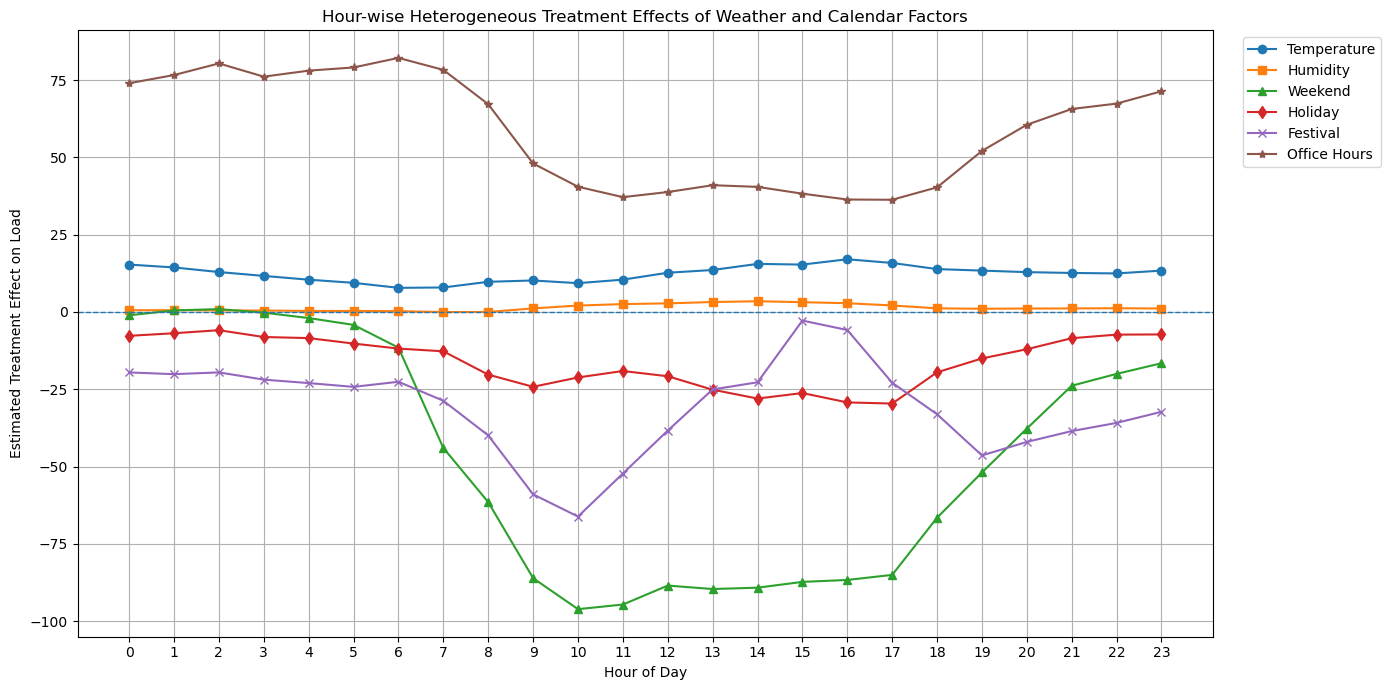

In [8]:
# =====================================================
# HOUR-WISE HETEROGENEOUS TREATMENT EFFECTS
# =====================================================

plot_df = pd.DataFrame({

    "hour": df["hour"],

    # Weather effects
    "Temperature": temp_effect,
    "Humidity": rh_effect,

    # Calendar / activity effects
    "Weekend": weekend_effect,
    "Holiday": holiday_effect,
    "Festival": festival_effect,
    "Office Hours": office_effect

})


# =====================================================
# GROUP EFFECTS BY HOUR
# =====================================================

hour_effect = (
    plot_df
    .groupby("hour")
    .mean()
    .reset_index()
)


# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(14, 7))


# Weather
plt.plot(
    hour_effect["hour"],
    hour_effect["Temperature"],
    marker="o",
    label="Temperature"
)

plt.plot(
    hour_effect["hour"],
    hour_effect["Humidity"],
    marker="s",
    label="Humidity"
)


# Calendar / Human Activity
plt.plot(
    hour_effect["hour"],
    hour_effect["Weekend"],
    marker="^",
    label="Weekend"
)

plt.plot(
    hour_effect["hour"],
    hour_effect["Holiday"],
    marker="d",
    label="Holiday"
)

plt.plot(
    hour_effect["hour"],
    hour_effect["Festival"],
    marker="x",
    label="Festival"
)

plt.plot(
    hour_effect["hour"],
    hour_effect["Office Hours"],
    marker="*",
    label="Office Hours"
)


# Zero reference line
plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)


# =====================================================
# LABELS
# =====================================================

plt.xlabel("Hour of Day")

plt.ylabel(
    "Estimated Treatment Effect on Load"
)

plt.title(
    "Hour-wise Heterogeneous Treatment Effects of Weather and Calendar Factors"
)

plt.xticks(range(24))

plt.grid(True)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

## Summary of Causal Inference Results

This section consolidates the Average Treatment Effects (ATEs) and Heterogeneous Treatment Effects (HTEs) calculated in the preceding causal analysis steps.

### Average Treatment Effects (ATEs)

These values represent the average causal impact of a one-unit change in the treatment variable on the electricity load, across the entire dataset. Confidence intervals (CIs) are also provided for each estimate.

In [9]:
print("\n--- Continuous Treatments ATEs ---")
print(f"Temperature (ATE): {ate_temp:.3f} (95% CI: [{temp_ci_final[0]:.3f}, {temp_ci_final[1]:.3f}])")
print(f"Humidity (ATE): {ate_rh:.3f} (95% CI: [{rh_ci_final[0]:.3f}, {rh_ci_final[1]:.3f}])")

print("\n--- Binary Treatments ATEs ---")
display(results)


--- Continuous Treatments ATEs ---
Temperature (ATE): 12.420 (95% CI: [9.853, 14.988])
Humidity (ATE): 1.377 (95% CI: [0.898, 1.855])

--- Binary Treatments ATEs ---


,Treatment,ATE,CI Lower,CI Upper
0,Weekend,-47.613119,-61.755712,-33.470526
1,Holiday,-16.054160,-37.805413,5.697094
2,Festival,-30.950687,-94.723826,32.822452
3,Office Hours,58.575271,-7.344506,124.495049


### Heterogeneous Treatment Effects (HTEs) by Hour

The following table shows the average heterogeneous treatment effects for each factor, grouped by the hour of the day. This provides insight into how the causal impact of each treatment varies throughout the day.

In [10]:
display(hour_effect)

,hour,Temperature,Humidity,Weekend,Holiday,Festival,Office Hours
0,0,15.318170,0.558499,-1.069730,-7.721930,-19.551937,73.972567
1,1,14.397868,0.569553,0.496827,-6.877471,-20.119654,76.615463
2,2,12.906635,0.495781,0.919302,-5.901175,-19.544440,80.364987
3,3,11.658723,0.464708,-0.230452,-8.102312,-21.886941,76.095204
4,4,10.434022,0.321957,-1.969173,-8.453758,-23.001723,78.038956
5,5,9.417683,0.325450,-4.183933,-10.225207,-24.222126,79.067432
6,6,7.799259,0.267459,-11.540641,-11.844920,-22.578786,82.159074
7,7,7.917160,-0.031911,-43.974134,-12.725214,-28.719891,78.281226
8,8,9.752866,0.007367,-61.487646,-20.266301,-39.928592,67.176893
9,9,10.179906,1.145241,-86.084863,-24.200057,-58.978215,48.012068


In [11]:
# ============================================================
# XAI ANALYSIS USING XGBOOST + SHAP
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import shap

# =====================================================
# Load Dataset (added to ensure 'df' is defined)
# =====================================================
# Debugging: List files in current directory to check for 'summer_2024 (1).csv'
!ls -l
df = pd.read_csv("summer_2024 (1).csv")
df = df.dropna().reset_index(drop=True)

# ------------------------------------------------------------
# 1. Prepare data
# ------------------------------------------------------------

# Features used for prediction
features = [
    "temp",
    "rh",
    "hour",
    "weekend",
    "holiday",
    "festival",
    "office_hours"
]

X_xai = df[features].copy()
y_xai = df["wdLoad"].copy()

# ------------------------------------------------------------
# 2. Train XGBoost model
# ------------------------------------------------------------

xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_xai, y_xai)

# Predictions
xai_predictions = xgb_model.predict(X_xai)

print("XGBoost XAI model trained successfully.")
print("Features used:", features)


total 13592
-rw-r--r--  1 ameypatil  staff  2484307 Sep  9 23:21 Copy_of_socioMonsoon_v2.ipynb
-rw-r--r--  1 ameypatil  staff   185104 Jul 19 10:43 WhatsApp Image 2026-07-16 at 00.20.01.jpeg
-rw-r--r--  1 ameypatil  staff   187279 Jul 19 10:43 WhatsApp Image 2026-07-16 at 00.20.16.jpeg
-rw-r--r--  1 ameypatil  staff   157861 Sep  9 19:57 autumnsocio.ipynb
-rw-r--r--  1 ameypatil  staff  2511568 Sep  9 23:19 autumnsocio_v2.ipynb
-rw-r--r--  1 ameypatil  staff   558808 Sep  9 23:21 socioSummer_with_LLM_v2.ipynb
-rw-r--r--@ 1 ameypatil  staff   175944 Jul 19 10:37 sociowinter.ipynb
-rw-r--r--  1 ameypatil  staff   632809 Sep  9 23:19 sociowinter_v2.ipynb


FileNotFoundError: [Errno 2] No such file or directory: 'summer_2024 (1).csv'

In [14]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print("\nFeature Importance:")
display(importance)

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

NameError: name 'features' is not defined

In [ ]:
# ============================================================
# SHAP ANALYSIS
# ============================================================

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_xai)

print("SHAP analysis completed.")

SHAP analysis completed.


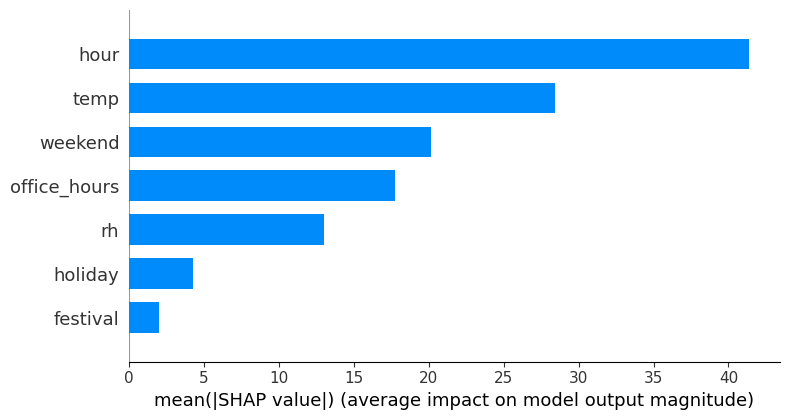

In [ ]:
# ============================================================
# GLOBAL SHAP IMPORTANCE
# ============================================================

shap.summary_plot(
    shap_values,
    X_xai,
    plot_type="bar"
)

In [13]:
# ============================================================
# SHAP BEESWARM
# ============================================================

shap.summary_plot(
    shap_values,
    X_xai
)

NameError: name 'shap_values' is not defined

In [ ]:
# ============================================================
# SHAP EVIDENCE
# ============================================================

# Calculate average absolute SHAP value
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_evidence = pd.DataFrame({
    "Feature": X_xai.columns,
    "Mean_Absolute_SHAP": mean_abs_shap
})

# Sort from most important to least important
shap_evidence = shap_evidence.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

# Add rank
shap_evidence["Rank"] = np.arange(1, len(shap_evidence) + 1)

print("SHAP Evidence")
display(shap_evidence)

SHAP Evidence


,Feature,Mean_Absolute_SHAP,Rank
0,hour,41.373688,1
1,temp,28.402878,2
2,weekend,20.177540,3
3,office_hours,17.757164,4
4,rh,13.007850,5
5,holiday,4.254437,6
6,festival,1.992249,7


In [ ]:
# ============================================================
# SHAP DIRECTION
# Based on the SHAP beeswarm interpretation
# ============================================================

shap_direction_map = {
    "hour": "Time-of-day is highly important",
    "temp": "Generally positive",
    "weekend": "Generally negative",
    "office_hours": "Generally positive",
    "rh": "Generally positive",
    "holiday": "Generally negative",
    "festival": "Generally negative"
}

shap_evidence["SHAP_Direction"] = (
    shap_evidence["Feature"].map(shap_direction_map)
)

display(shap_evidence)

,Feature,Mean_Absolute_SHAP,Rank,SHAP_Direction
0,hour,41.373688,1,Time-of-day is highly important
1,temp,28.402878,2,Generally positive
2,weekend,20.177540,3,Generally negative
3,office_hours,17.757164,4,Generally positive
4,rh,13.007850,5,Generally positive
5,holiday,4.254437,6,Generally negative
6,festival,1.992249,7,Generally negative


In [ ]:
# ============================================================
# XAI + CAUSAL EVIDENCE INTEGRATION
# ============================================================

# ------------------------------------------------------------
# 1. SHAP evidence
# ------------------------------------------------------------

mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_evidence = pd.DataFrame({
    "Feature": X_xai.columns,
    "Mean_Absolute_SHAP": mean_abs_shap
})

shap_evidence = shap_evidence.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

shap_evidence["SHAP_Rank"] = np.arange(
    1, len(shap_evidence) + 1
)


# ------------------------------------------------------------
# 2. SHAP direction
# ------------------------------------------------------------

directions = []

for i, feature in enumerate(X_xai.columns):

    feature_values = X_xai[feature].values
    feature_shap = shap_values[:, i]

    correlation = np.corrcoef(
        feature_values,
        feature_shap
    )[0, 1]

    if correlation > 0.1:
        direction = "Generally positive"

    elif correlation < -0.1:
        direction = "Generally negative"

    else:
        direction = "Mixed / weak"

    directions.append(direction)

shap_evidence["SHAP_Direction"] = directions


# ------------------------------------------------------------
# 3. Causal evidence
# ------------------------------------------------------------

causal_evidence = pd.DataFrame({

    "Feature": [
        "temp",
        "rh",
        "weekend",
        "holiday",
        "festival",
        "office_hours"
    ],

    "ATE": [
        ate_temp,
        ate_rh,
        weekend_ate,
        holiday_ate,
        festival_ate,
        office_ate
    ],

    "CI_Lower": [
        temp_ci_final[0],
        rh_ci_final[0],
        weekend_ci[0],
        holiday_ci[0],
        festival_ci[0],
        office_ci[0]
    ],

    "CI_Upper": [
        temp_ci_final[1],
        rh_ci_final[1],
        weekend_ci[1],
        holiday_ci[1],
        festival_ci[1],
        office_ci[1]
    ]
})


# ------------------------------------------------------------
# 4. Merge
# ------------------------------------------------------------

evidence = shap_evidence.merge(
    causal_evidence,
    on="Feature",
    how="left"
)


# ------------------------------------------------------------
# 5. Causal status
# ------------------------------------------------------------

def causal_status(row):

    # No causal ATE
    if pd.isna(row["ATE"]):
        return "Not estimated as treatment"

    # CI unavailable
    if pd.isna(row["CI_Lower"]) or pd.isna(row["CI_Upper"]):
        return "ATE estimated; CI not provided"

    # CI crosses zero
    if row["CI_Lower"] <= 0 and row["CI_Upper"] >= 0:
        return "CI crosses zero"

    # CI does not cross zero
    if row["ATE"] > 0:
        return "Positive estimated effect"

    if row["ATE"] < 0:
        return "Negative estimated effect"

    return "Near zero"


evidence["Causal_Status"] = evidence.apply(
    causal_status,
    axis=1
)


# ------------------------------------------------------------
# 6. Final table
# ------------------------------------------------------------

evidence = evidence[
    [
        "Feature",
        "SHAP_Rank",
        "Mean_Absolute_SHAP",
        "SHAP_Direction",
        "ATE",
        "CI_Lower",
        "CI_Upper",
        "Causal_Status"
    ]
]

print("==============================================")
print("XAI + CAUSAL EVIDENCE")
print("==============================================")

# ============================================================
# FINAL SHAP DIRECTIONS
# ============================================================

shap_direction_map = {
    "hour": "Time-of-day is highly important",
    "temp": "Generally positive",
    "weekend": "Generally negative",
    "office_hours": "Generally positive",
    "rh": "Generally positive",
    "holiday": "Generally negative",
    "festival": "Generally negative"
}

# Overwrite the existing direction column
evidence["SHAP_Direction"] = evidence["Feature"].map(shap_direction_map)

# Display only the final columns
evidence = evidence[
    [
        "Feature",
        "SHAP_Rank",
        "Mean_Absolute_SHAP",
        "SHAP_Direction",
        "ATE",
        "CI_Lower",
        "CI_Upper",
        "Causal_Status"
    ]
]

print("==============================================")
print("FINAL XAI + CAUSAL EVIDENCE")
print("==============================================")

display(evidence)
display(evidence)

XAI + CAUSAL EVIDENCE
FINAL XAI + CAUSAL EVIDENCE


,Feature,SHAP_Rank,Mean_Absolute_SHAP,SHAP_Direction,ATE,CI_Lower,CI_Upper,Causal_Status
0,hour,1,41.373688,Time-of-day is highly important,NaN,NaN,NaN,Not estimated as treatment
1,temp,2,28.402878,Generally positive,12.420236,9.852616,14.987856,Positive estimated effect
2,weekend,3,20.177540,Generally negative,-47.608265,-61.912269,-33.304261,Negative estimated effect
3,office_hours,4,17.757164,Generally positive,58.751286,-5.817170,123.319742,CI crosses zero
4,rh,5,13.007850,Generally positive,1.376763,0.898152,1.855374,Positive estimated effect
5,holiday,6,4.254437,Generally negative,-16.059595,-37.623790,5.504601,CI crosses zero
6,festival,7,1.992249,Generally negative,-31.069111,-97.219912,35.081691,CI crosses zero


,Feature,SHAP_Rank,Mean_Absolute_SHAP,SHAP_Direction,ATE,CI_Lower,CI_Upper,Causal_Status
0,hour,1,41.373688,Time-of-day is highly important,NaN,NaN,NaN,Not estimated as treatment
1,temp,2,28.402878,Generally positive,12.420236,9.852616,14.987856,Positive estimated effect
2,weekend,3,20.177540,Generally negative,-47.608265,-61.912269,-33.304261,Negative estimated effect
3,office_hours,4,17.757164,Generally positive,58.751286,-5.817170,123.319742,CI crosses zero
4,rh,5,13.007850,Generally positive,1.376763,0.898152,1.855374,Positive estimated effect
5,holiday,6,4.254437,Generally negative,-16.059595,-37.623790,5.504601,CI crosses zero
6,festival,7,1.992249,Generally negative,-31.069111,-97.219912,35.081691,CI crosses zero


In [ ]:
# ============================================================
# LLM-READY EVIDENCE OBJECT
# ============================================================

season_name = "Summer"

feature_names = {
    "temp": "Temperature",
    "rh": "Humidity",
    "hour": "Hour",
    "weekend": "Weekend",
    "holiday": "Holiday",
    "festival": "Festival",
    "office_hours": "Office Hours"
}

llm_evidence = {
    "season": season_name,

    "prediction_model": {
        "model": "XGBoost",
        "target": "wdLoad",
        "features": X_xai.columns.tolist()
    },

    "xai_evidence": [],

    "causal_evidence": [],

    "interpretation_rules": {
        "shap": "SHAP describes contribution to model predictions, not causality.",
        "econml": "EconML estimates treatment effects under stated causal assumptions.",
        "joint_states": "Joint calendar states are descriptive and should not be interpreted as separate causal effects."
    }
}


# ============================================================
# XAI EVIDENCE
# ============================================================

for _, row in evidence.iterrows():

    feature = row["Feature"]

    llm_evidence["xai_evidence"].append({

        "feature": feature_names.get(
            feature,
            feature
        ),

        "mean_abs_shap": round(
            row["Mean_Absolute_SHAP"],
            3
        ),

        "shap_rank": int(
            row["SHAP_Rank"]
        ),

        "shap_direction": row[
            "SHAP_Direction"
        ]
    })


# ============================================================
# CAUSAL EVIDENCE
# ============================================================

for _, row in evidence.iterrows():

    if pd.notna(row["ATE"]):

        ci_lower = row["CI_Lower"]
        ci_upper = row["CI_Upper"]

        llm_evidence["causal_evidence"].append({

            "feature": feature_names.get(
                row["Feature"],
                row["Feature"]
            ),

            "ate": round(
                row["ATE"],
                3
            ),

            "ci_lower": (
                round(ci_lower, 3)
                if pd.notna(ci_lower)
                else None
            ),

            "ci_upper": (
                round(ci_upper, 3)
                if pd.notna(ci_upper)
                else None
            ),

            "causal_status": row[
                "Causal_Status"
            ],

            "ci_crosses_zero": (
                pd.notna(ci_lower)
                and
                pd.notna(ci_upper)
                and
                ci_lower <= 0 <= ci_upper
            )
        })


print("LLM-Ready Evidence Object created successfully.")

# Uncomment to inspect:
# import pprint
# pprint.pprint(llm_evidence)

LLM-Ready Evidence Object created successfully.


In [ ]:
# ============================================================
# GROQ LLM - XAI + CAUSAL EVIDENCE INTEGRATION
# ============================================================

# Install Groq (Uncomment if you haven't installed it yet)
# !pip install -q groq

# ------------------------------------------------------------
# 1. IMPORTS
# ------------------------------------------------------------
import os
import json
from getpass import getpass
from groq import Groq

# ------------------------------------------------------------
# 2. ENTER GROQ API KEY
# ------------------------------------------------------------
if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass(
        "Enter your Groq API key: "
    )

# ------------------------------------------------------------
# 3. INITIALIZE GROQ CLIENT
# ------------------------------------------------------------
client = Groq(
    api_key=os.environ["GROQ_API_KEY"]
)
print("Groq client initialized successfully.")

# ------------------------------------------------------------
# 4. CHECK EVIDENCE OBJECT
# ------------------------------------------------------------
if "llm_evidence" not in globals():
    raise ValueError(
        "llm_evidence was not found. "
        "Run the LLM-Ready Evidence Object cell first."
    )

evidence_json = json.dumps(
    llm_evidence,
    indent=2,
    default=str
)

# ------------------------------------------------------------
# 5. DYNAMIC MODEL SELECTION (NEW FIX)
# ------------------------------------------------------------
print("Fetching currently active Groq models...")
available_models = [m.id for m in client.models.list().data]

# Prioritized list of reliable models to look for
preferred_models = [
    "llama3-8b-8192",         # Standard Llama 3
    "llama-3.1-8b-instant",   # Fast Llama 3.1
    "mixtral-8x7b-32768",     # Reliable Mixtral
    "gemma2-9b-it",           # Google Gemma
]

selected_model = None
for p_model in preferred_models:
    if p_model in available_models:
        selected_model = p_model
        break

# If none of our preferred models exist, just pick the first text model available
if not selected_model:
    text_models = [m for m in available_models if "whisper" not in m]
    selected_model = text_models[0] if text_models else available_models[0]

print(f"Automatically selected active model: {selected_model}")


# ------------------------------------------------------------
# 6. SYSTEM PROMPT
# ------------------------------------------------------------
system_prompt = """
You are an expert scientific analyst helping explain a
weather-driven electricity load analysis.

The analysis combines:

1. Explainable AI (SHAP)
2. Causal Machine Learning (EconML)
3. Large Language Model explanation

Your job is ONLY to interpret the validated evidence supplied
to you. Do not perform new statistical analysis.

IMPORTANT SCIENTIFIC RULES:

1. SHAP explains how features contributed to the predictions
   of the machine learning model.

2. SHAP is NOT causal evidence.

3. Never say that SHAP proves that a feature causes electricity
   load to change.

4. EconML estimates treatment effects under stated causal
   assumptions.

5. Never say that EconML mathematically proves causality.

6. If a confidence interval crosses zero, explicitly state that
   the estimated causal effect is uncertain and that the evidence
   does not establish a clear non-zero effect.

7. If a confidence interval does not cross zero, you may describe
   the estimated effect as having evidence of a non-zero effect
   under the stated causal assumptions.

8. Do not invent numerical values.

9. Do not calculate new ATEs, confidence intervals, significance
   values, correlations, or feature importance values.

10. Do not infer statistical significance from SHAP values.

11. Do not treat SHAP magnitude as causal effect magnitude.

12. If SHAP and EconML have the same direction, describe them as
    directionally consistent predictive and causal evidence.

13. If SHAP and EconML disagree in direction, explicitly mention
    the disagreement.

14. If a feature has no EconML treatment estimate, do not assign
    it a causal effect.

15. Hour represents time-of-day importance. It must not be
    interpreted as a causal treatment effect when it is not
    estimated as a treatment.

16. Joint calendar/activity states are descriptive evidence only.
    Do not interpret them as separate causal effects.

17. Use the exact evidence provided in the input.

18. Do not introduce outside facts about electricity demand,
    weather, holidays, or energy systems unless necessary for
    explaining the supplied evidence.

Write in clear, simple, academically appropriate language.

The explanation must contain these four sections:

1. Overall Finding
2. Feature-wise Interpretation
3. Agreement Between XAI and Causal Evidence
4. Important Limitations

For feature-wise interpretation:

- Mention SHAP importance where available.
- Mention SHAP direction where available.
- Mention EconML ATE and confidence interval where available.
- Clearly distinguish predictive evidence from causal evidence.
- Do not overstate uncertain results.

Keep the answer concise and suitable for inclusion in a
research project report.
"""

# ------------------------------------------------------------
# 7. USER PROMPT
# ------------------------------------------------------------
user_prompt = f"""
Analyze the following validated evidence from the
weather-driven electricity load study.

The evidence contains SHAP-based predictive explanations and
EconML-based causal treatment-effect estimates.

IMPORTANT:
Use only the evidence supplied below.

Validated Evidence:

{evidence_json}

Generate the scientific interpretation using the required
four-section structure.
"""

# ------------------------------------------------------------
# 8. CALL GROQ
# ------------------------------------------------------------
print(f"\nGenerating LLM explanation using {selected_model}...\n")

response = client.chat.completions.create(
    model=selected_model,  # Automatically populated with a valid model
    messages=[
        {
            "role": "system",
            "content": system_prompt
        },
        {
            "role": "user",
            "content": user_prompt
        }
    ],
    temperature=0.2,
    max_tokens=1500
)

# ------------------------------------------------------------
# 9. EXTRACT RESPONSE
# ------------------------------------------------------------
llm_explanation = response.choices[0].message.content

# ------------------------------------------------------------
# 10. DISPLAY FINAL EXPLANATION
# ------------------------------------------------------------
print("=" * 70)
print("LLM-GENERATED XAI + CAUSAL INTERPRETATION")
print("=" * 70)
print(llm_explanation)

# ------------------------------------------------------------
# 11. OPTIONAL: STORE RESULT
# ------------------------------------------------------------
llm_result = {
    "season": llm_evidence.get("season") if isinstance(llm_evidence, dict) else None,
    "evidence": llm_evidence,
    "llm_explanation": llm_explanation
}

print("\n")
print("=" * 70)
print("LLM EVIDENCE INTEGRATION COMPLETED SUCCESSFULLY")
print("=" * 70)

Groq client initialized successfully.
Fetching currently active Groq models...
Automatically selected active model: openai/gpt-oss-safeguard-20b

Generating LLM explanation using openai/gpt-oss-safeguard-20b...

LLM-GENERATED XAI + CAUSAL INTERPRETATION
**1. Overall Finding**  
The XGBoost model for summer electricity load identifies time‑of‑day as the most influential predictor, followed by temperature, weekend status, office hours, humidity, holiday, and festival. Causal analysis with EconML confirms a statistically robust positive effect of temperature and a negative effect of weekends on load. The causal estimates for office hours, holiday, and festival are uncertain because their confidence intervals include zero. Humidity shows a small but significant positive causal effect. Thus, while predictive importance aligns with causal evidence for temperature and weekends, other calendar and weather variables exhibit only predictive or uncertain causal signals.

**2. Feature‑wise Interpr

Selected Day: 2024-03-04

SINGLE-DAY HOURLY TREATMENT EFFECTS
Date: 2024-03-04


,hour,Temperature,Humidity,Weekend,Holiday,Festival,Office Hours
0,0,14.235693,0.664686,-2.787412,-4.533891,-25.970808,127.288853
1,1,13.049901,0.722601,-1.476307,-4.729282,-65.881435,143.589524
2,2,11.612955,0.580992,-3.027732,-5.513660,-64.093113,143.006042
3,3,10.718913,0.560332,-4.084351,-7.259963,-19.709410,139.122245
4,4,9.490841,0.429959,-7.146390,-6.217842,-33.507047,142.442742
5,5,8.508013,0.427429,-11.380612,-8.143547,-41.159321,133.796400
6,6,6.778626,0.244802,-19.591842,-19.232304,-22.449699,117.818866
7,7,7.575717,-0.273256,-43.150051,-19.364189,-34.386500,119.476888
8,8,10.301937,-0.244199,-53.333366,-23.536676,-53.865696,126.131148
9,9,11.444024,0.885971,-63.393205,-24.584124,-114.747714,93.983801


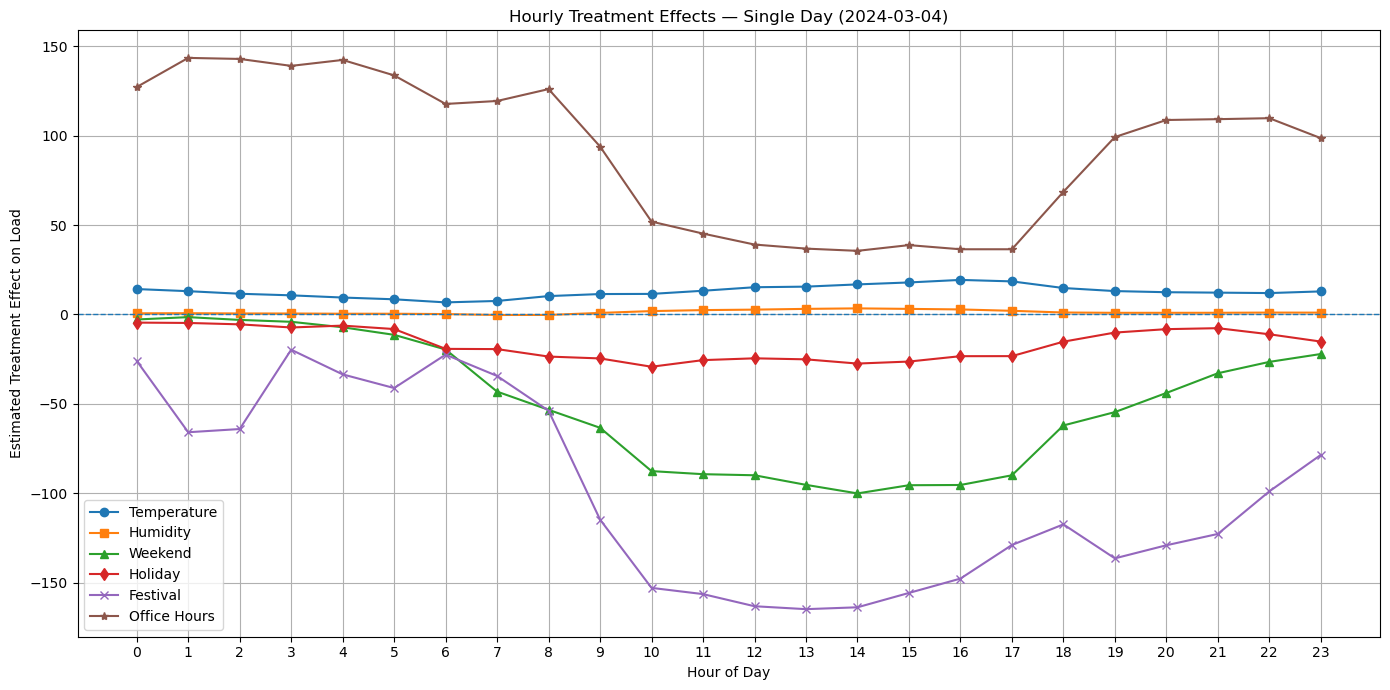

In [12]:
# =====================================================
# SINGLE-DAY HOURLY TREATMENT EFFECTS
# SUMMER 2024
# =====================================================

# -----------------------------------------------------
# 1. Create date column
# -----------------------------------------------------

df["date"] = pd.to_datetime(df["datetime"]).dt.date


# -----------------------------------------------------
# 2. Select one random day from the dataset
# -----------------------------------------------------

selected_date = np.random.choice(
    df["date"].unique()
)

print("Selected Day:", selected_date)


# -----------------------------------------------------
# 3. Create treatment-effect dataframe
# -----------------------------------------------------

single_day_df = pd.DataFrame({

    "date": df["date"],
    "hour": df["hour"],

    # Weather effects
    "Temperature": temp_effect,
    "Humidity": rh_effect,

    # Calendar / activity effects
    "Weekend": weekend_effect,
    "Holiday": holiday_effect,
    "Festival": festival_effect,
    "Office Hours": office_effect

})


# -----------------------------------------------------
# 4. Keep ONLY the selected day
# -----------------------------------------------------

single_day_df = single_day_df[
    single_day_df["date"] == selected_date
].copy()


# -----------------------------------------------------
# 5. Calculate hourly treatment effects
# -----------------------------------------------------
#
# If there are multiple observations within an hour
# (e.g. 15-minute observations), average ONLY those
# observations within that hour.
#
# There is NO averaging across different days.
# -----------------------------------------------------

single_day_hour_effect = (
    single_day_df
    .groupby("hour")
    [
        [
            "Temperature",
            "Humidity",
            "Weekend",
            "Holiday",
            "Festival",
            "Office Hours"
        ]
    ]
    .mean()
    .reset_index()
)


# =====================================================
# 6. DISPLAY RESULTS
# =====================================================

print("\n==============================================")
print("SINGLE-DAY HOURLY TREATMENT EFFECTS")
print("==============================================")

print("Date:", selected_date)

display(single_day_hour_effect)


# =====================================================
# 7. PLOT
# =====================================================

plt.figure(figsize=(14, 7))


# -----------------------------------------------------
# WEATHER EFFECTS
# -----------------------------------------------------

plt.plot(
    single_day_hour_effect["hour"],
    single_day_hour_effect["Temperature"],
    marker="o",
    label="Temperature"
)

plt.plot(
    single_day_hour_effect["hour"],
    single_day_hour_effect["Humidity"],
    marker="s",
    label="Humidity"
)


# -----------------------------------------------------
# CALENDAR / ACTIVITY EFFECTS
# -----------------------------------------------------

plt.plot(
    single_day_hour_effect["hour"],
    single_day_hour_effect["Weekend"],
    marker="^",
    label="Weekend"
)

plt.plot(
    single_day_hour_effect["hour"],
    single_day_hour_effect["Holiday"],
    marker="d",
    label="Holiday"
)

plt.plot(
    single_day_hour_effect["hour"],
    single_day_hour_effect["Festival"],
    marker="x",
    label="Festival"
)

plt.plot(
    single_day_hour_effect["hour"],
    single_day_hour_effect["Office Hours"],
    marker="*",
    label="Office Hours"
)


# -----------------------------------------------------
# ZERO REFERENCE
# -----------------------------------------------------

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)


# -----------------------------------------------------
# LABELS
# -----------------------------------------------------

plt.xlabel("Hour of Day")

plt.ylabel(
    "Estimated Treatment Effect on Load"
)

plt.title(
    f"Hourly Treatment Effects — Single Day ({selected_date})"
)

plt.xticks(range(24))

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()